# Desigualdade de Renda nos Estados Brasileiros (2012–2024)
### Uma Análise Exploratória via IPEA Data

**Autor:** Gabriel Ribeiro Passos    
**Métodos:** Análise exploratória de painel · Estatísticas descritivas · Visualização  

---

**Pergunta central:** Como evoluiu a desigualdade de renda entre os estados brasileiros entre 2012 e 2024, e quais estados convergiram ou divergiram da média nacional?

---

### Estrutura do Notebook
1. Instalação e Importações
2. Coleta de Dados
3. Limpeza e Montagem do Painel
4. Análise Descritiva
5. Visualizações
6. Exportação

## 1. Instalação e Importações

In [1]:
# Instalar bibliotecas não nativas do Colab
!pip install ipeadatapy geobr -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.0/338.0 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 58.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 45.4 MB/s eta 0:00:00


In [2]:
# Importar bibliotecas
import requests
import pandas as pd
import ipeadatapy as ipea
import geopandas as gpd
import geobr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import os
from matplotlib.colors import TwoSlopeNorm
from google.colab import files
import zipfile

# Configuração visual padrão para todos os gráficos
plt.rcParams.update({
    'figure.dpi': 150,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8fafc',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.4,
    'grid.linestyle': '--',
    'font.size': 11,
})

CORES_REGIAO = {
    'Norte':        '#06b6d4',
    'Nordeste':     '#f59e0b',
    'Sudeste':      '#ff0000',
    'Sul':          '#10b981',
    'Centro-Oeste': '#8b5cf6'
}

# Criar pastas de saída
os.makedirs('outputs/graficos', exist_ok=True)

## 2. Coleta de Dados

In [3]:
# Importar códigos IPEADATA e buscar série de interesse
codigos = ipea.list_series()
codigos

codigos[codigos.CODE.str.contains("GINI")]

URL = "http://ipeadata.gov.br/api/odata4/ValoresSerie(SERCODIGO='PNADCA_GINIUF')"

response = requests.get(URL)
response.raise_for_status()

df_bruto = pd.DataFrame(response.json()['value'])

print(f"Linhas coletadas: {len(df_bruto)}")
print(f"Colunas: {df_bruto.columns.tolist()}")
print(f"Níveis territoriais: {df_bruto["NIVNOME"].unique()}")

Linhas coletadas: 429
Colunas: ['SERCODIGO', 'VALDATA', 'VALVALOR', 'NIVNOME', 'TERCODIGO']
Níveis territoriais: ['Brasil' 'Regiões' 'Estados']


## 3. Limpeza e Montagem do Painel

In [4]:
# Dicionários de referência
NOMES_UF = {
    11: 'Rondônia',           12: 'Acre',
    13: 'Amazonas',           14: 'Roraima',
    15: 'Pará',               16: 'Amapá',
    17: 'Tocantins',          21: 'Maranhão',
    22: 'Piauí',              23: 'Ceará',
    24: 'Rio Grande do Norte', 25: 'Paraíba',
    26: 'Pernambuco',         27: 'Alagoas',
    28: 'Sergipe',            29: 'Bahia',
    31: 'Minas Gerais',       32: 'Espírito Santo',
    33: 'Rio de Janeiro',     35: 'São Paulo',
    41: 'Paraná',             42: 'Santa Catarina',
    43: 'Rio Grande do Sul',  50: 'Mato Grosso do Sul',
    51: 'Mato Grosso',        52: 'Goiás',
    53: 'Distrito Federal'
}

REGIOES = {
    'Rondônia': 'Norte',           'Acre': 'Norte',
    'Amazonas': 'Norte',           'Roraima': 'Norte',
    'Pará': 'Norte',               'Amapá': 'Norte',
    'Tocantins': 'Norte',          'Maranhão': 'Nordeste',
    'Piauí': 'Nordeste',           'Ceará': 'Nordeste',
    'Rio Grande do Norte': 'Nordeste', 'Paraíba': 'Nordeste',
    'Pernambuco': 'Nordeste',      'Alagoas': 'Nordeste',
    'Sergipe': 'Nordeste',         'Bahia': 'Nordeste',
    'Minas Gerais': 'Sudeste',     'Espírito Santo': 'Sudeste',
    'Rio de Janeiro': 'Sudeste',   'São Paulo': 'Sudeste',
    'Paraná': 'Sul',               'Santa Catarina': 'Sul',
    'Rio Grande do Sul': 'Sul',    'Mato Grosso do Sul': 'Centro-Oeste',
    'Mato Grosso': 'Centro-Oeste', 'Goiás': 'Centro-Oeste',
    'Distrito Federal': 'Centro-Oeste'
}

# Limpeza
gini = (
    df_bruto
    .query("NIVNOME == 'Estados'")
    .rename(columns={'VALDATA': 'ano', 'VALVALOR': 'gini', 'TERCODIGO': 'cod_uf'})
    .assign(
        ano    = lambda x: pd.to_datetime(x['ano'], utc=True).dt.year,
        cod_uf = lambda x: x['cod_uf'].astype(int),
        gini   = lambda x: x['gini'].astype(float),
    )
    [['ano', 'cod_uf', 'gini']]
    .assign(
        uf     = lambda x: x['cod_uf'].map(NOMES_UF),
        regiao = lambda x: x['uf'].map(REGIOES),
    )
    .reset_index(drop=True)
)

# Validação
assert len(gini) == 351,       f"Esperado 351 linhas, encontrado {len(gini)}"
assert gini['uf'].nunique() == 27, "Número de UFs incorreto"
assert gini.isnull().sum().sum() == 0, "Há valores ausentes"

print(f"  Observações : {len(gini)}")
print(f"  UFs únicas  : {gini['uf'].nunique()}")
gini.head()

  Observações : 351
  UFs únicas  : 27


,ano,cod_uf,gini,uf,regiao
0,2012,12,0.566,Acre,Norte
1,2012,27,0.503,Alagoas,Nordeste
2,2012,13,0.589,Amazonas,Norte
3,2012,16,0.528,Amapá,Norte
4,2012,29,0.563,Bahia,Nordeste


In [5]:
# Salvar painel tratado
gini.to_csv('painel_gini.csv', index=False)

## 4. Análise Descritiva

In [6]:
# Por ano
stats_ano = gini.groupby('ano')['gini'].agg(
    media='mean', mediana='median', minimo='min', maximo='max', dp='std'
).round(4)

# Por região
stats_regiao = gini.groupby('regiao')['gini'].agg(
    media='mean', mediana='median', minimo='min', maximo='max', dp='std'
).round(4).sort_values('media', ascending=False)

# Por UF (média do período)
stats_uf = gini.groupby(['uf', 'regiao'])['gini'].agg(
    media='mean', minimo='min', maximo='max'
).round(4).sort_values('media', ascending=False)

# Variação 2012 - 2024 por UF
variacao_uf = (
    gini[gini['ano'].isin([2012, 2024])]
    .pivot_table(index=['uf', 'regiao'], columns='ano', values='gini')
    .dropna()
    .reset_index()
)
variacao_uf.columns = ['uf', 'regiao', 'gini_2012', 'gini_2024']
variacao_uf['variacao_pct'] = (
    (variacao_uf['gini_2024'] - variacao_uf['gini_2012']) / variacao_uf['gini_2012'] * 100
).round(2)

# Convergência: desvio padrão entre UFs por ano
convergencia = gini.groupby('ano')['gini'].std().round(4)
dp_2012 = convergencia[2012]
dp_2024 = convergencia[2024]
queda_conv = ((dp_2024 - dp_2012) / dp_2012 * 100).round(1)

print("=== EVOLUÇÃO NACIONAL (média simples entre UFs) ===")
print(stats_ano.to_string())
print(f"\n=== CONVERGÊNCIA ===")
print(f"Desvio padrão entre UFs — 2012: {dp_2012:.4f} | 2024: {dp_2024:.4f} | Variação: {queda_conv}%")
print("\n=== GINI MÉDIO POR REGIÃO ===")
print(stats_regiao.to_string())
print("\n=== TOP 5 MAIS DESIGUAIS (média 2012–2024) ===")
print(stats_uf.head(5).to_string())
print("\n=== TOP 5 MAIS IGUALITÁRIOS ===")
print(stats_uf.tail(5).to_string())
print("\n=== 3 MAIORES REDUÇÕES ===")
print(variacao_uf.nsmallest(3, 'variacao_pct')[['uf', 'regiao', 'gini_2012', 'gini_2024', 'variacao_pct']].to_string(index=False))
print("\n=== 2 PIORES DESEMPENHOS ===")
print(variacao_uf.nlargest(2, 'variacao_pct')[['uf', 'regiao', 'gini_2012', 'gini_2024', 'variacao_pct']].to_string(index=False))

=== EVOLUÇÃO NACIONAL (média simples entre UFs) ===
       media  mediana  minimo  maximo      dp
ano                                          
2012  0.5189    0.508   0.435   0.601  0.0396
2013  0.5133    0.513   0.428   0.581  0.0395
2014  0.5044    0.510   0.408   0.574  0.0385
2015  0.5068    0.515   0.414   0.581  0.0413
2016  0.5156    0.524   0.421   0.579  0.0404
2017  0.5187    0.525   0.414   0.593  0.0455
2018  0.5252    0.538   0.417   0.578  0.0378
2019  0.5240    0.530   0.421   0.581  0.0430
2020  0.4967    0.500   0.412   0.548  0.0370
2021  0.5230    0.530   0.424   0.596  0.0440
2022  0.5004    0.508   0.419   0.558  0.0341
2023  0.4961    0.492   0.418   0.559  0.0328
2024  0.4878    0.489   0.431   0.547  0.0301

=== CONVERGÊNCIA ===
Desvio padrão entre UFs — 2012: 0.0396 | 2024: 0.0301 | Variação: -24.0%

=== GINI MÉDIO POR REGIÃO ===
               media  mediana  minimo  maximo      dp
regiao                                               
Nordeste      0.5302   0

## 5. Visualizações

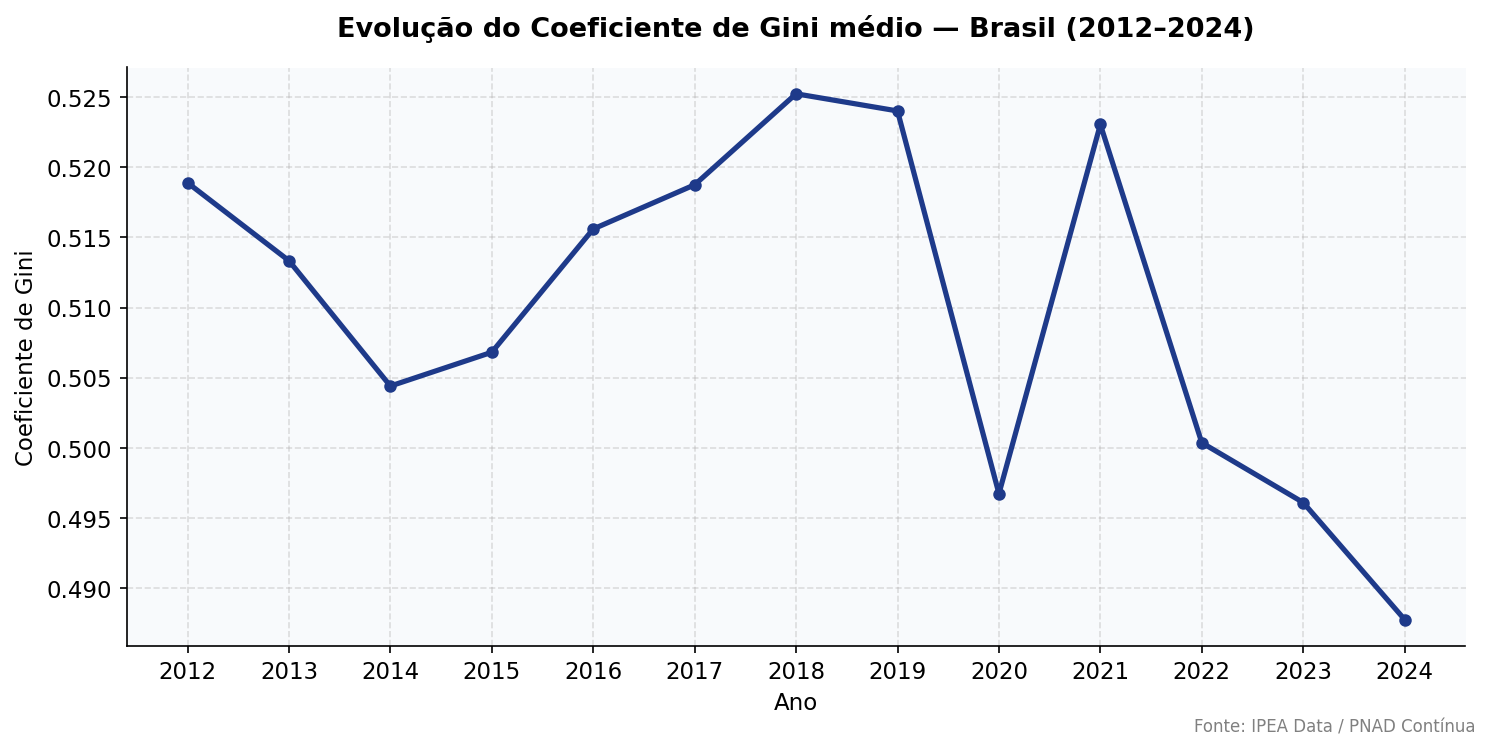

In [7]:
# Gráfico 1 — Evolução do Gini médio nacional
por_ano = gini.groupby('ano')['gini'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(por_ano['ano'], por_ano['gini'],
        color='#1e3a8a', linewidth=2.5, marker='o', markersize=5)
ax.set_title('Evolução do Coeficiente de Gini médio — Brasil (2012–2024)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Ano')
ax.set_ylabel('Coeficiente de Gini')
ax.set_xticks(por_ano['ano'])
plt.figtext(0.99, 0.01, 'Fonte: IPEA Data / PNAD Contínua',
            ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.savefig('outputs/graficos/01_gini_nacional.png', bbox_inches='tight')
plt.show()

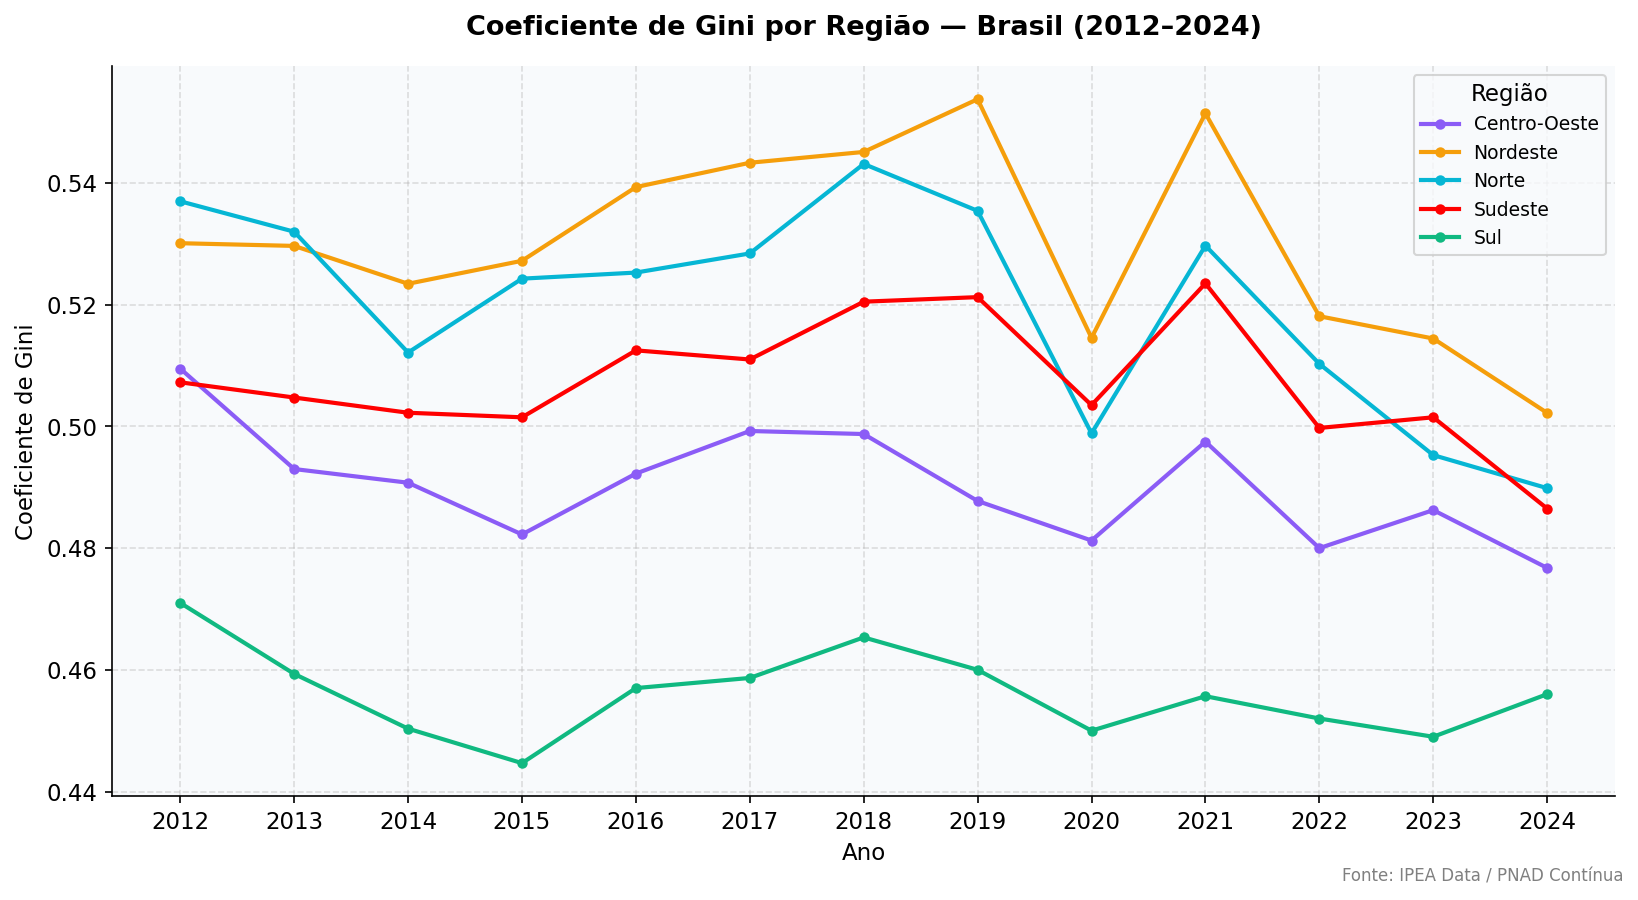

In [8]:
# Gráfico 2 — Gini por região
por_regiao = gini.groupby(['ano', 'regiao'])['gini'].mean().reset_index()

fig, ax = plt.subplots(figsize=(11, 6))
for regiao, grupo in por_regiao.groupby('regiao'):
    ax.plot(grupo['ano'], grupo['gini'],
            label=regiao, color=CORES_REGIAO[regiao],
            linewidth=2, marker='o', markersize=4)
ax.set_title('Coeficiente de Gini por Região — Brasil (2012–2024)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Ano')
ax.set_ylabel('Coeficiente de Gini')
ax.legend(title='Região', fontsize=9)
ax.set_xticks(sorted(gini['ano'].unique()))
plt.figtext(0.99, 0.01, 'Fonte: IPEA Data / PNAD Contínua',
            ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.savefig('outputs/graficos/02_gini_por_regiao.png', bbox_inches='tight')
plt.show()

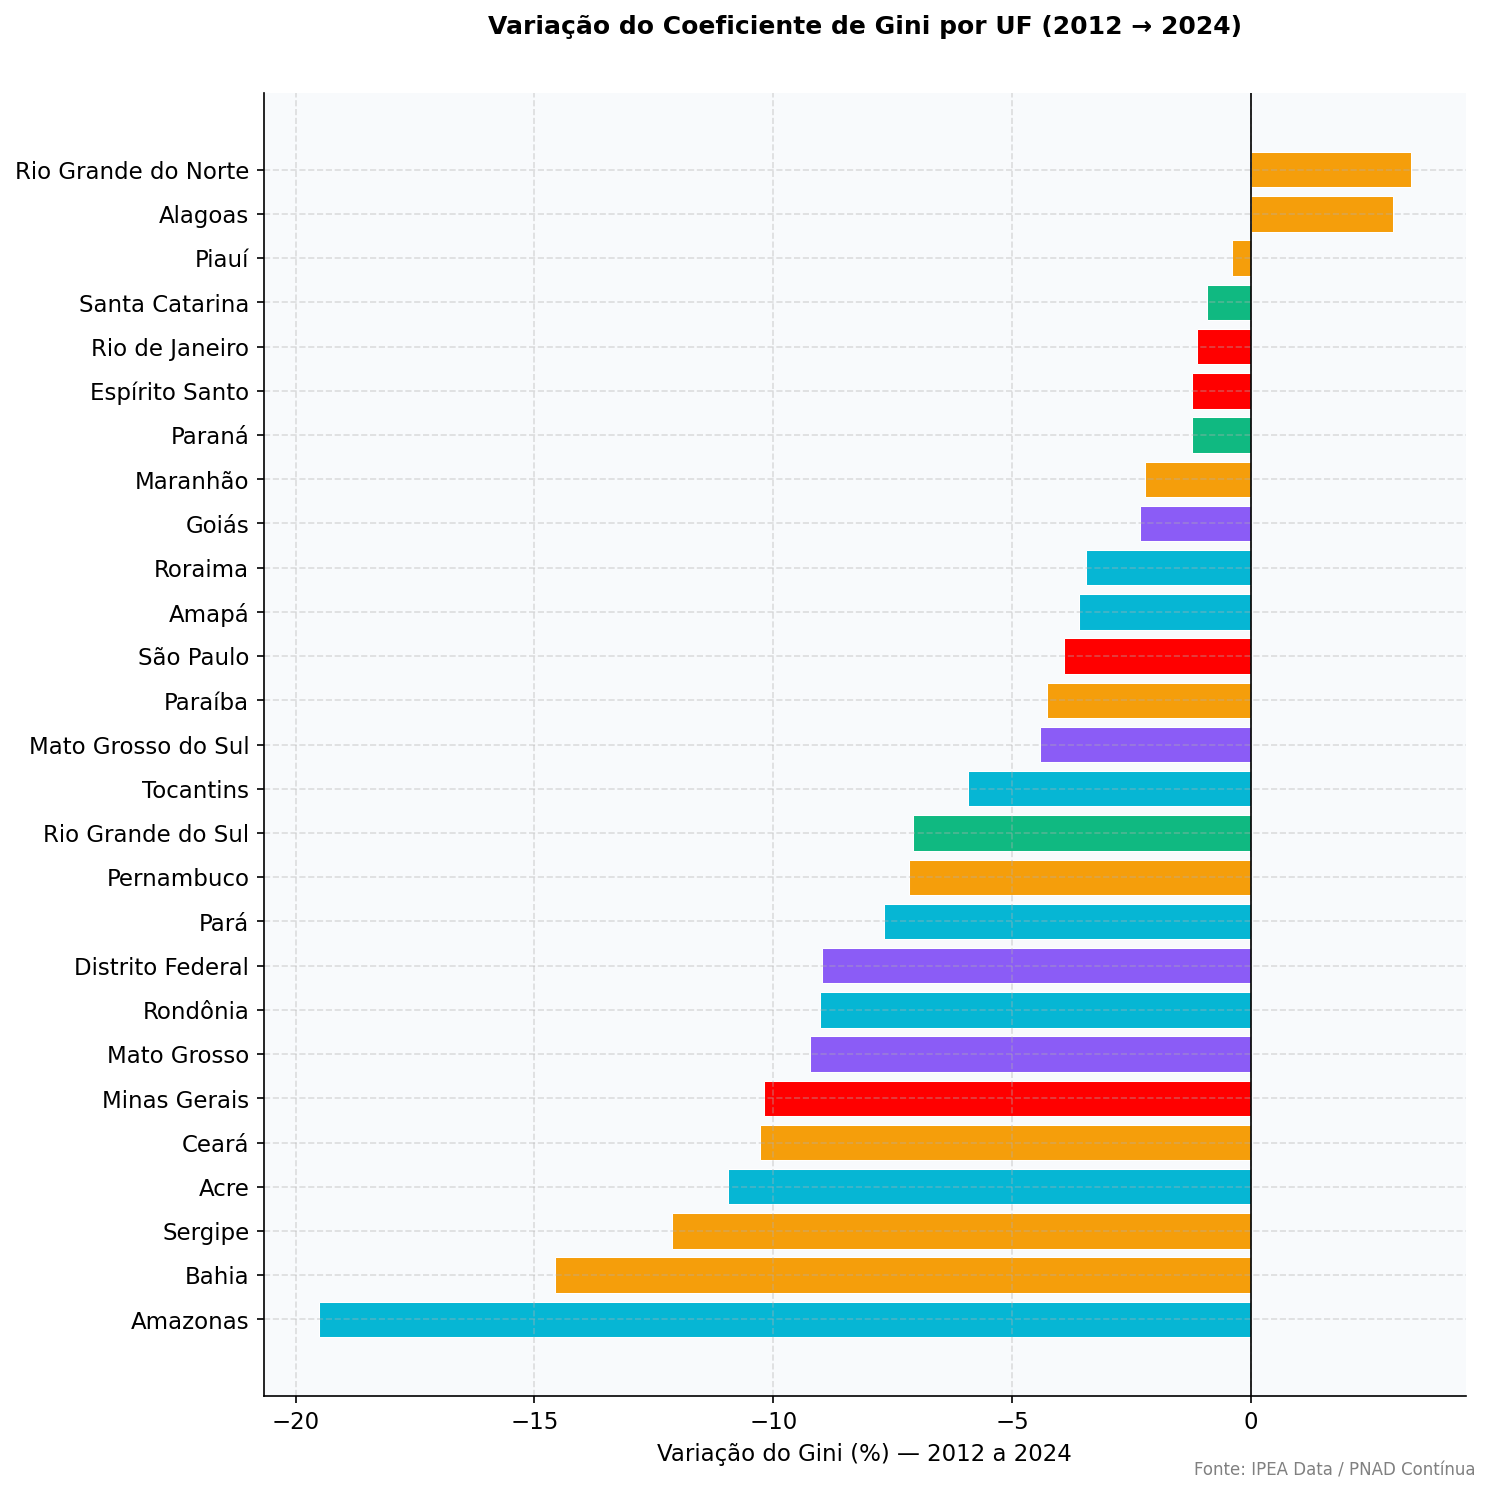

In [9]:
# Gráfico 3 — Ranking de UFs por variação percentual
ranking = variacao_uf.sort_values('variacao_pct').assign(
    cor=lambda x: x['regiao'].map(CORES_REGIAO)
)

fig, ax = plt.subplots(figsize=(10, 10))
ax.barh(ranking['uf'], ranking['variacao_pct'],
        color=ranking['cor'], edgecolor='white', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Variação do Gini (%) — 2012 a 2024')
ax.set_title('Variação do Coeficiente de Gini por UF (2012 → 2024)\n',
             fontsize=12, fontweight='bold', pad=15)
plt.figtext(0.99, 0.01, 'Fonte: IPEA Data / PNAD Contínua',
            ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.savefig('outputs/graficos/03_ranking_ufs.png', bbox_inches='tight')
plt.show()

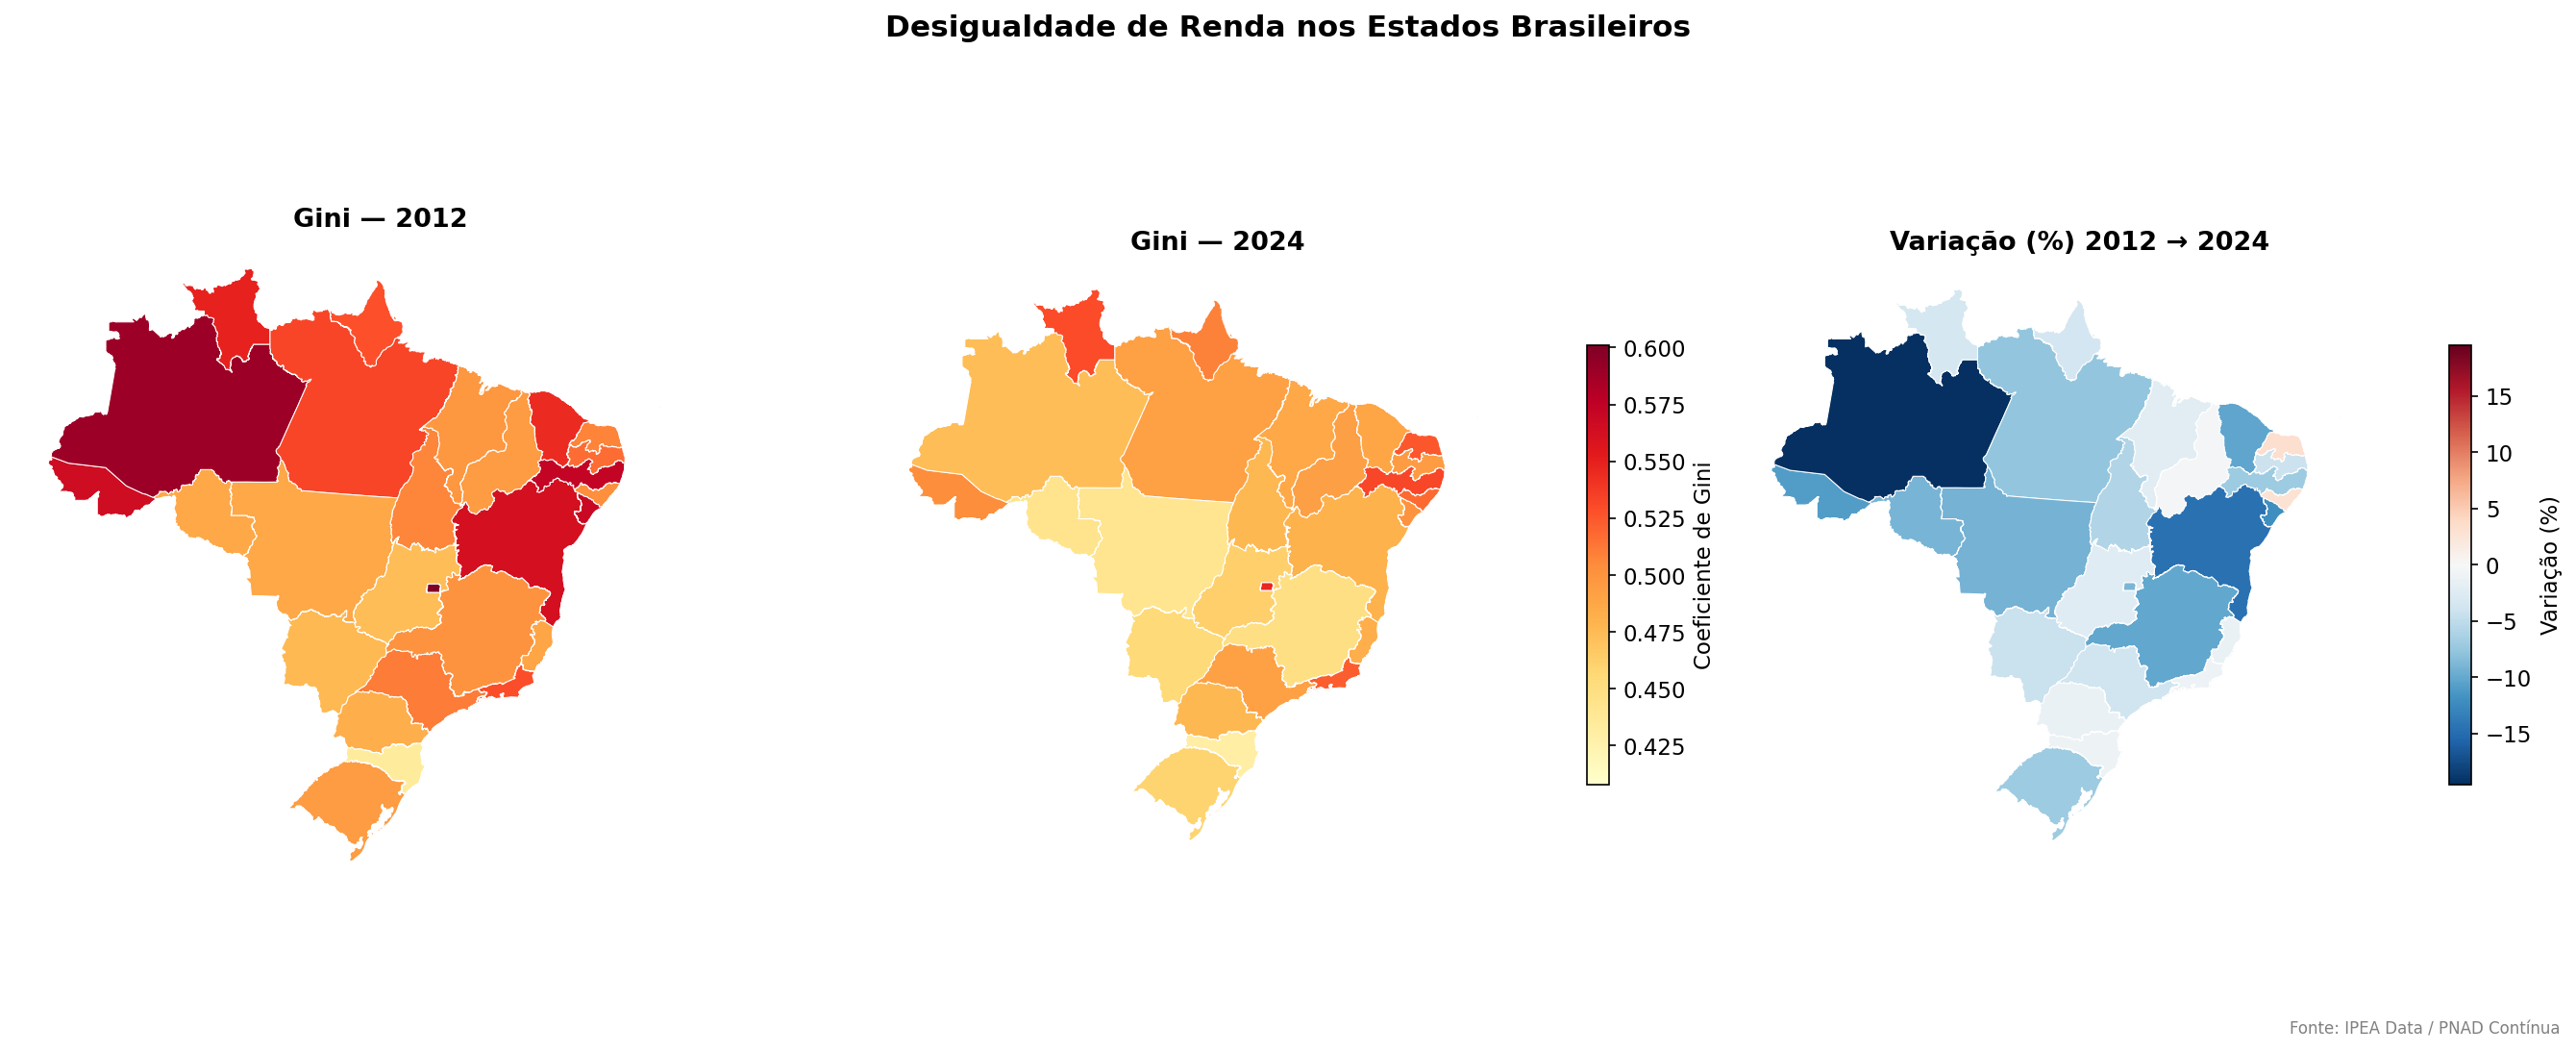

In [10]:
# Gráfico 4 — Mapa: Gini 2012, Gini 2024 e variação
if 'cod_uf' not in variacao_uf.columns:
    cod_map = gini[['uf', 'cod_uf']].drop_duplicates()
    variacao_uf = variacao_uf.merge(cod_map, on='uf', how='left')


estados = geobr.read_state(year=2020, simplified=True)
estados['code_state'] = estados['code_state'].astype(int)

mapa = estados.merge(
    variacao_uf[['cod_uf', 'gini_2012', 'gini_2024', 'variacao_pct']],
    left_on='code_state',
    right_on='cod_uf',
    how='left'
)

vmin, vmax = gini['gini'].min(), gini['gini'].max()

abs_max = max(abs(variacao_uf['variacao_pct'].min()),
              abs(variacao_uf['variacao_pct'].max()))

norm_var = TwoSlopeNorm(
    vmin=-abs_max,
    vcenter=0,
    vmax=abs_max
)

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

mapa.plot(column='gini_2012', ax=axes[0], cmap='YlOrRd',
          vmin=vmin, vmax=vmax, edgecolor='white', linewidth=0.5)
axes[0].set_title('Gini — 2012', fontsize=13, fontweight='bold')
axes[0].axis('off')

mapa.plot(column='gini_2024', ax=axes[1], cmap='YlOrRd',
          vmin=vmin, vmax=vmax, edgecolor='white', linewidth=0.5)
axes[1].set_title('Gini — 2024', fontsize=13, fontweight='bold')
axes[1].axis('off')

mapa.plot(column='variacao_pct', ax=axes[2], cmap='RdBu_r',
          norm=norm_var, edgecolor='white', linewidth=0.5)
axes[2].set_title('Variação (%) 2012 → 2024', fontsize=13, fontweight='bold')
axes[2].axis('off')

sm1 = plt.cm.ScalarMappable(cmap='YlOrRd', norm=mcolors.Normalize(vmin=vmin, vmax=vmax))
sm2 = plt.cm.ScalarMappable(cmap='RdBu_r', norm=norm_var)
sm1.set_array([])
sm2.set_array([])

fig.colorbar(sm1, ax=axes[1], fraction=0.03, pad=0.04, label='Coeficiente de Gini')
fig.colorbar(sm2, ax=axes[2], fraction=0.03, pad=0.04, label='Variação (%)')

plt.suptitle('Desigualdade de Renda nos Estados Brasileiros',
             fontsize=15, fontweight='bold', y=1.02)
plt.figtext(0.99, 0.01, 'Fonte: IPEA Data / PNAD Contínua',
            ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.savefig('outputs/graficos/04_mapas_Brasil.png', bbox_inches='tight')
plt.show()

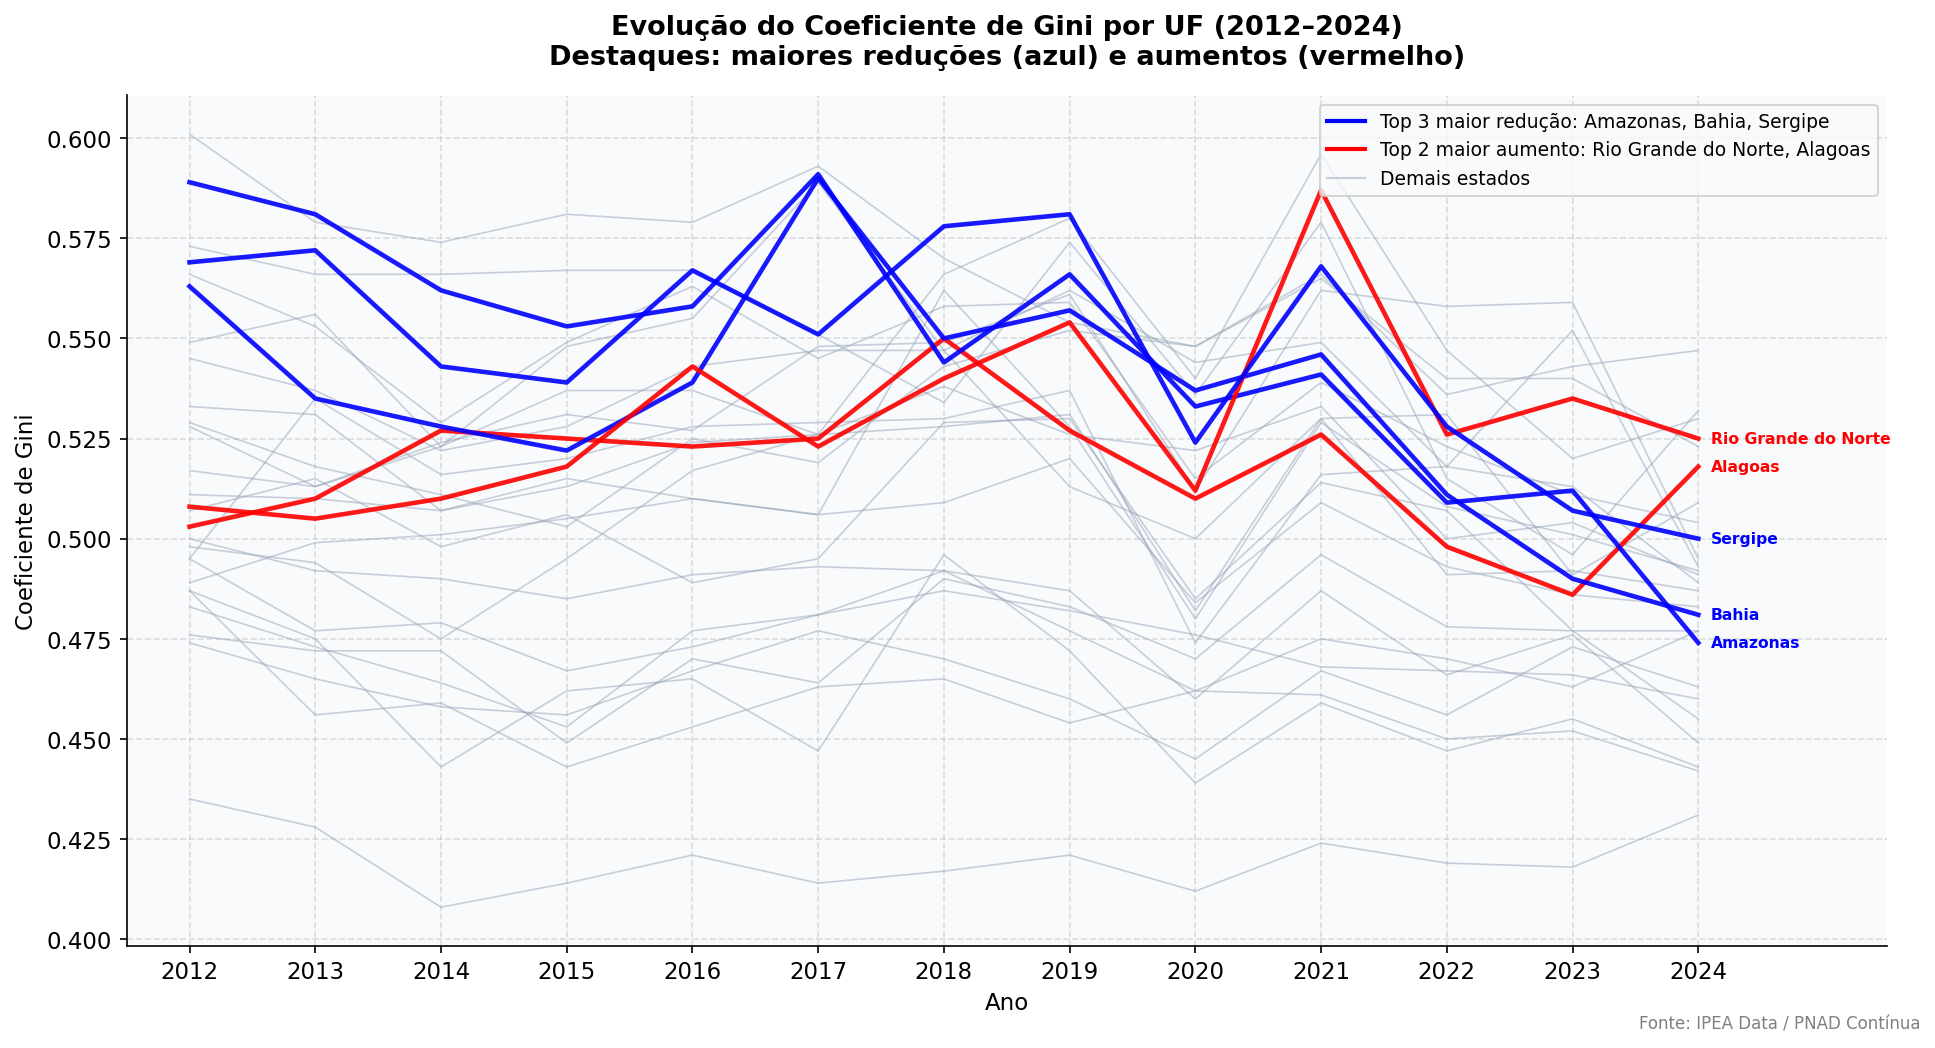

In [11]:
# Gráfico 5 — Evolução por UF com destaques
top3 = variacao_uf.nsmallest(3, 'variacao_pct')['uf'].tolist()
top2 = variacao_uf.nlargest(2,  'variacao_pct')['uf'].tolist()

fig, ax = plt.subplots(figsize=(13, 7))

for uf, grupo in gini.groupby('uf'):
    grupo = grupo.sort_values('ano')
    if uf in top3:
        ax.plot(grupo['ano'], grupo['gini'],
                color='#0000ff', linewidth=2.2, zorder=3, alpha=0.9)
        ax.text(grupo['ano'].iloc[-1] + 0.1, grupo['gini'].iloc[-1],
                uf, fontsize=7.5, color='#0000ff', fontweight='bold', va='center')
    elif uf in top2:
        ax.plot(grupo['ano'], grupo['gini'],
                color='#ff0000', linewidth=2.2, zorder=3, alpha=0.9)
        ax.text(grupo['ano'].iloc[-1] + 0.1, grupo['gini'].iloc[-1],
                uf, fontsize=7.5, color='#ff0000', fontweight='bold', va='center')
    else:
        ax.plot(grupo['ano'], grupo['gini'],
                color='#94a3b8', linewidth=0.8, zorder=2, alpha=0.5)

legend_elements = [
    Line2D([0], [0], color='#0000ff', linewidth=2, label=f'Top 3 maior redução: {", ".join(top3)}'),
    Line2D([0], [0], color='#ff0000', linewidth=2, label=f'Top 2 maior aumento: {", ".join(top2)}'),
    Line2D([0], [0], color='#94a3b8', linewidth=1, alpha=0.5, label='Demais estados'),
]
ax.legend(handles=legend_elements, fontsize=9, loc='upper right')
ax.set_title('Evolução do Coeficiente de Gini por UF (2012–2024)\n'
             'Destaques: maiores reduções (azul) e aumentos (vermelho)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Ano')
ax.set_ylabel('Coeficiente de Gini')
ax.set_xticks(sorted(gini['ano'].unique()))
ax.set_xlim(2011.5, 2025.5)
plt.figtext(0.99, 0.01, 'Fonte: IPEA Data / PNAD Contínua',
            ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.savefig('outputs/graficos/05_evolucao_por_uf.png', bbox_inches='tight')
plt.show()

## 6. Exportação

In [12]:
# Salvar painel
with pd.ExcelWriter('painel_gini.xlsx', engine='openpyxl') as writer:
    gini.to_excel(writer, sheet_name='Painel', index=False)
    stats_ano.to_excel(writer, sheet_name='Stats por Ano')
    stats_regiao.to_excel(writer, sheet_name='Stats por Região')
    stats_uf.to_excel(writer, sheet_name='Stats por UF')
    variacao_uf.to_excel(writer, sheet_name='Variação por UF', index=False)

print("Salvo: painel_gini.xlsx com 5 abas")

# Zipar todos os outputs
with zipfile.ZipFile('outputs.zip', 'w') as z:
    for pasta, _, arquivos in os.walk('outputs'):
        for arquivo in arquivos:
            caminho = os.path.join(pasta, arquivo)
            z.write(caminho)
    z.write('painel_gini.xlsx')

files.download('outputs.zip')
print("Download iniciado: outputs.zip")

Salvo: painel_gini.xlsx com 5 abas


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download iniciado: outputs.zip
